# Prosit — Régression Linéaire Immobilière
## Loft’s Craft — Prédiction du prix médian des logements

**Contexte :** La société immobilière Loft’s Craft souhaite automatiser la prédiction du prix médian des logements par *block group* à partir de variables explicatives (latitude, longitude, revenu médian, population, etc.). On utilise le dataset **California Housing** (sklearn).

**Objectifs :**
1. Construire un pipeline complet de préparation des données
2. Entraîner un modèle de régression linéaire
3. Évaluer le modèle avec validation croisée (R², MSE)
4. Identifier le sur-apprentissage éventuel

---
## 1. Chargement et exploration des données

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Chargement du dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dimensions :", df.shape)
print("\nDescription des variables :")
print(housing.DESCR[:900])


Dimensions : (20640, 9)

Description des variables :
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousa


In [31]:
# Aperçu des premières lignes
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [32]:
# Statistiques descriptives
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [33]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


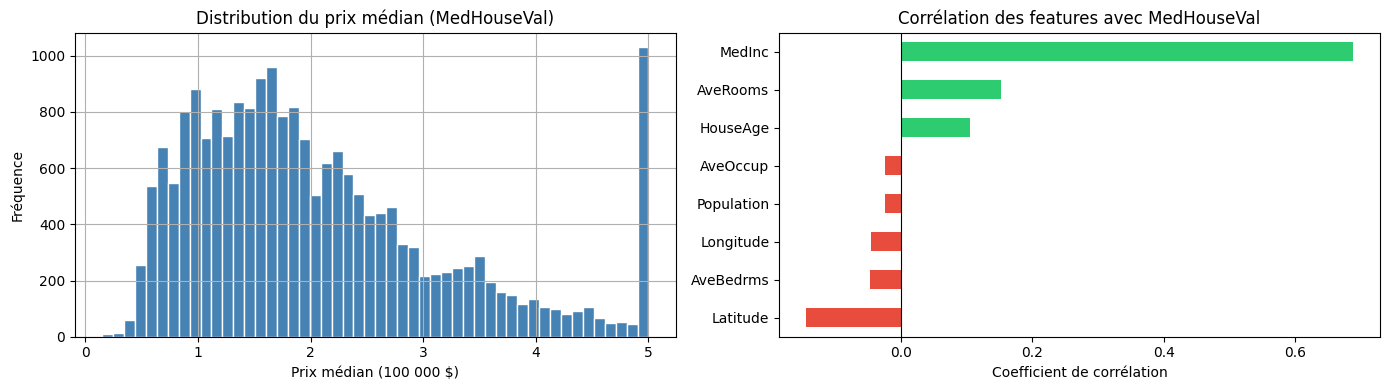


Correlations avec MedHouseVal :
Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
Name: MedHouseVal, dtype: float64


In [34]:
# Distribution de la variable cible (MedHouseVal)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['MedHouseVal'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix médian (MedHouseVal)')
axes[0].set_xlabel('Prix médian (100 000 $)')
axes[0].set_ylabel('Fréquence')

# Corrélation avec la cible
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
corr.plot(kind='barh', ax=axes[1], color=['#e74c3c' if c < 0 else '#2ecc71' for c in corr])
axes[1].set_title('Corrélation des features avec MedHouseVal')
axes[1].set_xlabel('Coefficient de corrélation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nCorrelations avec MedHouseVal :")
print(corr)

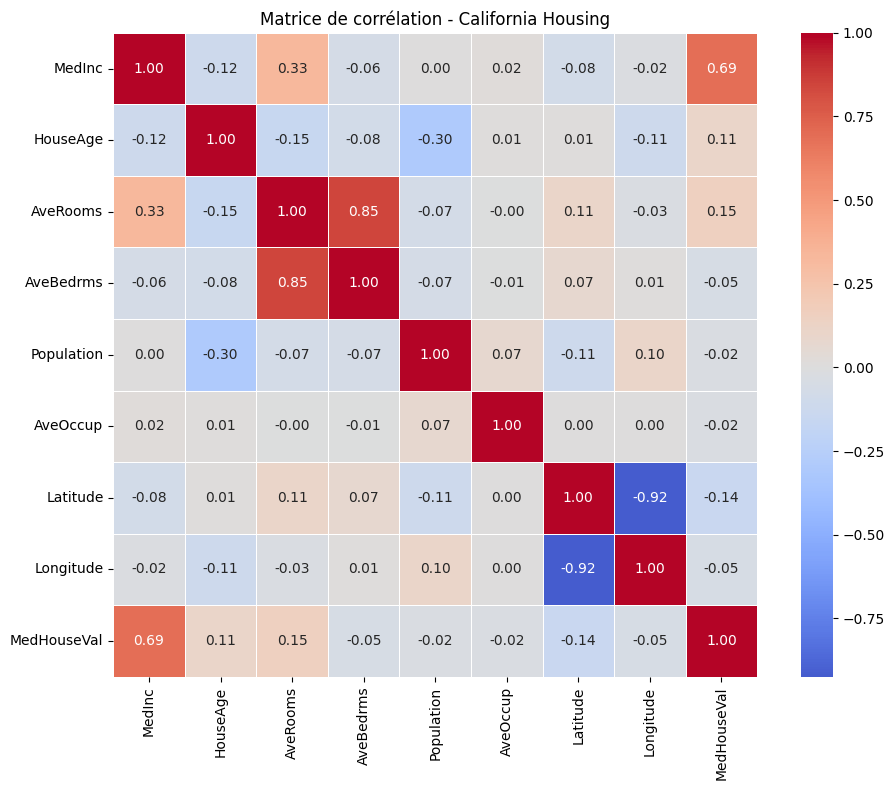

In [35]:
# Matrice de corrélation complète
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matrice de corrélation - California Housing')
plt.tight_layout()
plt.show()

---
## 2. Préparation des données (Pipeline)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Séparation features / cible
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille jeu d'entraînement : {X_train.shape}")
print(f"Taille jeu de test        : {X_test.shape}")

Taille jeu d'entraînement : (16512, 8)
Taille jeu de test        : (4128, 8)


In [37]:
from sklearn.linear_model import LinearRegression

# Pipeline avec normalisation StandardScaler
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

models = {
    'Régression Linéaire': pipeline_lr,
}

print("Pipeline créé avec succès.")

Pipeline créé avec succès.


---
## 3. Validation croisée et métriques (R², MSE)

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

cv_results = {}

print(f"{'Modèle':<25} {'R² moyen (CV)':<18} {'R² std':<12} {'MSE moyen (CV)':<18} {'MSE std'}")
print('-' * 90)

for name, pipeline in models.items():
    # Validation croisée 5-fold
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    neg_mse_scores = cross_val_score(pipeline, X_train, y_train, cv=5,
                                      scoring='neg_mean_squared_error')
    mse_scores = -neg_mse_scores  # retourner en positif

    cv_results[name] = {
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'mse_mean': mse_scores.mean(),
        'mse_std': mse_scores.std(),
    }

    print(f"{name:<25} {r2_scores.mean():<18.4f} {r2_scores.std():<12.4f} "
          f"{mse_scores.mean():<18.4f} {mse_scores.std():.4f}")

Modèle                    R² moyen (CV)      R² std       MSE moyen (CV)     MSE std
------------------------------------------------------------------------------------------
Régression Linéaire       0.6115             0.0065       0.5193             0.0149


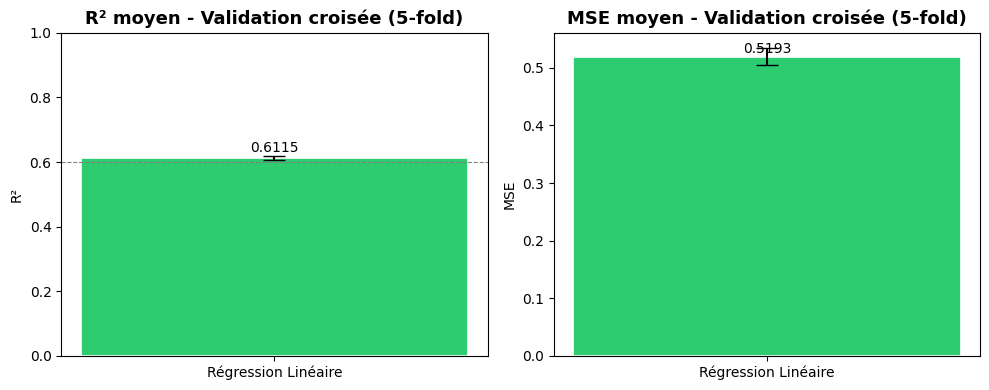

In [39]:
# Visualisation R² et MSE
names = list(cv_results.keys())
r2_means = [cv_results[n]['r2_mean'] for n in names]
r2_stds = [cv_results[n]['r2_std'] for n in names]
mse_means = [cv_results[n]['mse_mean'] for n in names]
mse_stds = [cv_results[n]['mse_std'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# R²
bars1 = axes[0].bar(names, r2_means, yerr=r2_stds, capsize=8,
                     color=['#2ecc71'], edgecolor='white', linewidth=1.2)
axes[0].set_title('R² moyen - Validation croisée (5-fold)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.6, linestyle='--', color='gray', linewidth=0.8, label='Seuil 0.6')
for bar, val in zip(bars1, r2_means):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# MSE
bars2 = axes[1].bar(names, mse_means, yerr=mse_stds, capsize=8,
                     color=['#2ecc71'], edgecolor='white', linewidth=1.2)
axes[1].set_title('MSE moyen - Validation croisée (5-fold)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MSE')
for bar, val in zip(bars2, mse_means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
## 4. Évaluation sur le jeu de test

In [40]:
test_results = {}

print(f"{'Modèle':<25} {'R² (test)':<15} {'MSE (test)':<15} {'RMSE (test)'}")
print('-' * 65)

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    test_results[name] = {'r2': r2, 'mse': mse, 'rmse': rmse, 'y_pred': y_pred}
    print(f"{name:<25} {r2:<15.4f} {mse:<15.4f} {rmse:.4f}")

Modèle                    R² (test)       MSE (test)      RMSE (test)
-----------------------------------------------------------------
Régression Linéaire       0.5758          0.5559          0.7456


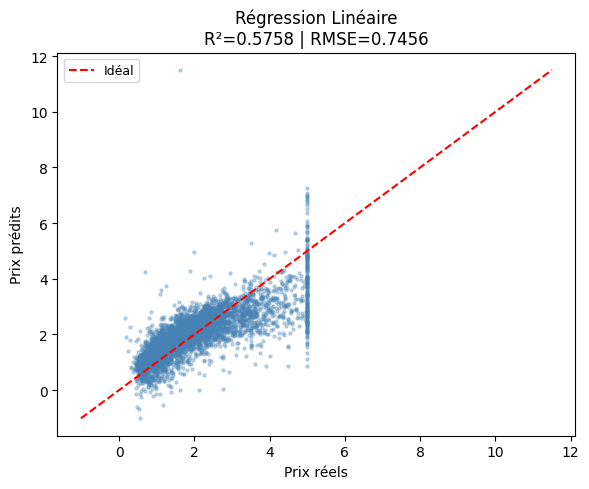

In [41]:
# Graphe Prédictions vs Réalité
name = 'Régression Linéaire'
res = test_results[name]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, res['y_pred'], alpha=0.3, s=5, color='steelblue')
lim_min = min(y_test.min(), res['y_pred'].min())
lim_max = max(y_test.max(), res['y_pred'].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Idéal')
ax.set_xlabel('Prix réels')
ax.set_ylabel('Prix prédits')
ax.set_title(f'{name}\nR²={res["r2"]:.4f} | RMSE={res["rmse"]:.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Analyse du sur-apprentissage

In [42]:
# Comparaison R² train vs test pour détecter le sur-apprentissage
print(f"{'Modèle':<25} {'R² train':<15} {'R² test':<15} {'Différence (surapprentissage ?)'}")
print('-' * 80)

overfitting_data = {}
for name, pipeline in models.items():
    y_pred_train = pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = test_results[name]['r2']
    diff = r2_train - r2_test
    flag = '⚠️ SURAPPRENTISSAGE' if diff > 0.05 else 'OK'
    overfitting_data[name] = {'r2_train': r2_train, 'r2_test': r2_test, 'diff': diff}
    print(f"{name:<25} {r2_train:<15.4f} {r2_test:<15.4f} {diff:.4f}  {flag}")

Modèle                    R² train        R² test         Différence (surapprentissage ?)
--------------------------------------------------------------------------------
Régression Linéaire       0.6126          0.5758          0.0368  OK


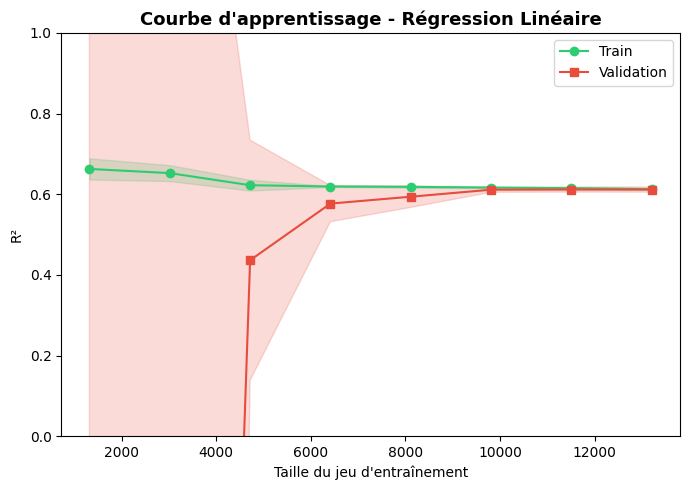

In [43]:
# Courbe d'apprentissage pour visualiser le sur-apprentissage
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_lr, X_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2ecc71', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='#2ecc71')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', color='#e74c3c', label='Validation')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='#e74c3c')
ax.set_title("Courbe d'apprentissage - Régression Linéaire", fontsize=13, fontweight='bold')
ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel('R²')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## 6. Résumé et conclusion

In [44]:
# Évaluation finale sur le jeu de test
print('=' * 60)
print('RÉSUMÉ FINAL - Performances sur le jeu de test')
print('=' * 60)
print(f"{'Modèle':<25} {'R²':<12} {'MSE':<12} {'RMSE'}")
print('-' * 60)

pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"{'Régression Linéaire':<25} {r2:<12.4f} {mse:<12.4f} {rmse:.4f}")
print('=' * 60)
print("\n→ Le RMSE est exprimé en centaines de milliers de dollars (100 000 $).")
print("→ Un R² proche de 1 indique un modèle qui explique bien la variance.")

RÉSUMÉ FINAL - Performances sur le jeu de test
Modèle                    R²           MSE          RMSE
------------------------------------------------------------
Régression Linéaire       0.5758       0.5559       0.7456

→ Le RMSE est exprimé en centaines de milliers de dollars (100 000 $).
→ Un R² proche de 1 indique un modèle qui explique bien la variance.


---
## Conclusion

Ce prosit nous a permis de :
- **Entraîner un modèle** de régression linéaire
- **Évaluer rigoureusement** avec la validation croisée 5-fold (R², MSE)
- **Détecter le sur-apprentissage** via la courbe d'apprentissage

**Points de vigilance** :
- La validation croisée est indispensable pour évaluer la capacité de généralisation
- Un R² identique en train et test indique qu’il n’y a pas de sur-apprentissage